In [3]:
import pandas as pd
import kagglehub
import os
import re
import string

from wordcloud import WordCloud
from langdetect import detect, DetectorFactory
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

c:\Users\wenli\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wenli\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wenli\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wenli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\wenli\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading p

**Data Preprocessing**

In [4]:
# data import
# original source:https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch

In [5]:
# Download latest version
path = kagglehub.dataset_download("nikhileswarkomati/suicide-watch")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\wenli\.cache\kagglehub\datasets\nikhileswarkomati\suicide-watch\versions\14


In [6]:
all_files = os.listdir(path)
all_files

['Suicide_Detection.csv']

In [7]:
pd.set_option('display.max_colwidth', None)

In [8]:
file_path = os.path.join(path, 'Suicide_Detection.csv')
df = pd.read_csv(file_path)
df.sample(5)

,Unnamed: 0,text,class
143336,215116,A message to all people that think NNN should be cancelled due to corona You are pathetic and should be ashamed for even thinking it should be cancelled,non-suicide
198700,298142,"What the fuck did I do? What the fuck can I do?I paid a super sexy tweaker girl for a skype show last night. Turns out she's high risk. I triggered her inadvertently by referencing the borderline personality disorder she mentioned. After a few hours of several confusing, alarming message exchanges, she claimed to have attempted suicide and stopped responding.\n\nNow she claims (general post on her tumblr, not to me) to have failed in her attempt. I messaged her the number for her local mental health crisis services, no response.\n\nI'm worried sick for this person I barely know who I may have pushed over an edge I couldn't recognize. How do those of you committed to preventing suicide deal with this blind brinksmanship, this constant eggshell walk?",suicide
15483,23352,"My Unusual Way of CopingMy Dad gave me a Ruger Blackhawk before he died. He and I were close, real close. I took care of him for the final months of his sickness. And, even though I was the only one to come see him and care for him, he always was the highlight of my day. Then, when he passed, my wife and I shortly thereafter divorced. She thought I was too emotionally detached or unstable. After those two hard hits (happening within a month of each other), I came home from work one day and grabbed the handgun. I placed it against my temple and pulled the trigger. **click**. I never did buy bullets. I cried for hours after that. I was happy I didn't die and petrified of living another moment. Ever since then, I'll come home after a day where my depression is more severe than others and put the gun to my head and pull the trigger. Sometimes once, sometimes more. It's so soothing. It calms me down.",suicide
149241,223959,Dont hate on this rewind pls [https://www.youtube.com/watch?v=ldQlVis0DL4](https://www.youtube.com/watch?v=ldQlVis0DL4),non-suicide
167635,251494,I need help How do you guys know if you have Alzheimer’s,non-suicide


In [9]:
df.head()

,Unnamed: 0,text,class
0,2,"Ex Wife Threatening SuicideRecently I left my wife for good because she has cheated on me twice and lied to me so much that I have decided to refuse to go back to her. As of a few days ago, she began threatening suicide. I have tirelessly spent these paat few days talking her out of it and she keeps hesitating because she wants to believe I'll come back. I know a lot of people will threaten this in order to get their way, but what happens if she really does? What do I do and how am I supposed to handle her death on my hands? I still love my wife but I cannot deal with getting cheated on again and constantly feeling insecure. I'm worried today may be the day she does it and I hope so much it doesn't happen.",suicide
1,3,Am I weird I don't get affected by compliments if it's coming from someone I know irl but I feel really good when internet strangers do it,non-suicide
2,4,"Finally 2020 is almost over... So I can never hear ""2020 has been a bad year"" ever again. I swear to fucking God it's so annoying",non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’ve been struggling for years and I’m afraid. Through these past years thoughts of suicide, fear, anxiety I’m so close to my limit . I’ve been quiet for so long and I’m too scared to come out to my family about these feelings. About 3 years ago losing my aunt triggered it all. Everyday feeling hopeless , lost, guilty, and remorseful over her and all the things I’ve done in my life,but thoughts like these with the little I’ve experienced in life? Only time I’ve revealed these feelings to my family is when I broke down where they saw my cuts. Watching them get so worried over something I portrayed as an average day made me feel absolutely dreadful. They later found out I was an attempt survivor from attempt OD(overdose from pills) and attempt hanging. All that happened was a blackout from the pills and I never went through with the noose because I’m still so afraid. During my first therapy I was diagnosed with severe depression, social anxiety, and a eating disorder.\nI was later transferred to a fucken group therapy for some reason which made me feel more anxious. Eventually before my last session with a 1 on 1 therapy she showed me my results from a daily check up on my feelings(which was a 2 - step survey for me and my mom/dad )\nCome to find out as I’ve been putting feeling horrible and afraid/anxious everyday , my mom has been doing I’ve been doing absolutely amazing with me described as “happiest she’s ever seen me, therapy has helped him” \nI eventually was put on Sertaline (anti anxiety or anti depression I’m sorry I forgot) but I never finished my first prescription nor ever found the right type of anti depressant because my mom thought I only wanted the drugs so she took me off my recommended pill schedule after ~3 week and stopped me from taking them. All this time I’ve been feeling worse afraid of the damage/ worry I’ve caused them even more. \nNow here with everything going on, I’m as afraid as I’ve ever been . I’ve relapsed on cutting and have developed severe insomnia . Day after day feeling more hopeless, worthless questioning why am I still here? What’s my motivation to move out of bed and keep going? I ask these to myself nearly every night almost having a break down everytime. \nPlease Please Please someone.. anyone help me.\nI’m so scared I might do something drastic, I’ve been shaped by fear and anxiety. Idk what to do anymore",suicide


In [10]:
df.shape

(232074, 3)

In [11]:
# total 232074 rows
df.count()

Unnamed: 0    232074
text          232074
class         232074
dtype: int64

In [12]:
df.dtypes

Unnamed: 0    int64
text            str
class           str
dtype: object

In [13]:
# check balance of classes
df['class'].value_counts()

class
suicide        116037
non-suicide    116037
Name: count, dtype: int64

In [14]:
df = df.drop('Unnamed: 0', axis=1)

In [15]:
df['text_len'] = df['text'].apply(len)

In [16]:
df['text_len'].max()

np.int64(40297)

In [17]:
df['text_len'].mean()

np.float64(689.6397356015754)

In [18]:
df['text_len'].min()

np.int64(3)

In [19]:
df.shape

(232074, 3)

In [20]:
# check for "filler" pattern
# "filler" is a valid word, but sometimes used to fill space
filler_data = df[df["text"].str.contains('filler filler', case=False)]
filler_data.sample(10)

,text,class,text_len
90957,Okay songs sometimes have disturbing lyricses But WAP takes it to another level...\n\nFiller filler filler filler filler filler filler filler,non-suicide,139
112185,Join amongus Filler Filler ARA ARA the code is LGBTQ,non-suicide,52
176402,These BLM niggas want me to care about them more than i care about myself 💀 filler filler filler filler filler filler filler filler filler filler,non-suicide,145
21734,Welp boys i got rona and so does my whole family What the fuck is I do for the next 2 weeks\n\nFiller filler filler filler filler idler d didjdjsksnd dnd djdjd disks,non-suicide,165
161485,Wisconsin doesn’t exist Filler filler filler filler filler,non-suicide,58
111142,what’s a good movie to watch preferably one that’s not too loud\n\nfiller filler filler follerfioler filler,non-suicide,105
62815,"This is my third attempt at making a post Shhhhhhhh! There's a girl Among us, and I'm sorry i gotta make this filler filler filler filler filler filler filler filler filler",non-suicide,172
52271,Number one way to get a girl? Filler filler Filler filler Filler filler Filler filler Filler filler Filler filler,non-suicide,113
228940,Does anyone wanna talk [14] Filler filler filler filler filler filler filler filler filler filler filler,non-suicide,104
58389,hey dm me if u wanna play the number game filler filler filler filler filler filler filler filler filler filler,non-suicide,111


**EDA**:explorre the relationship between class type and text length

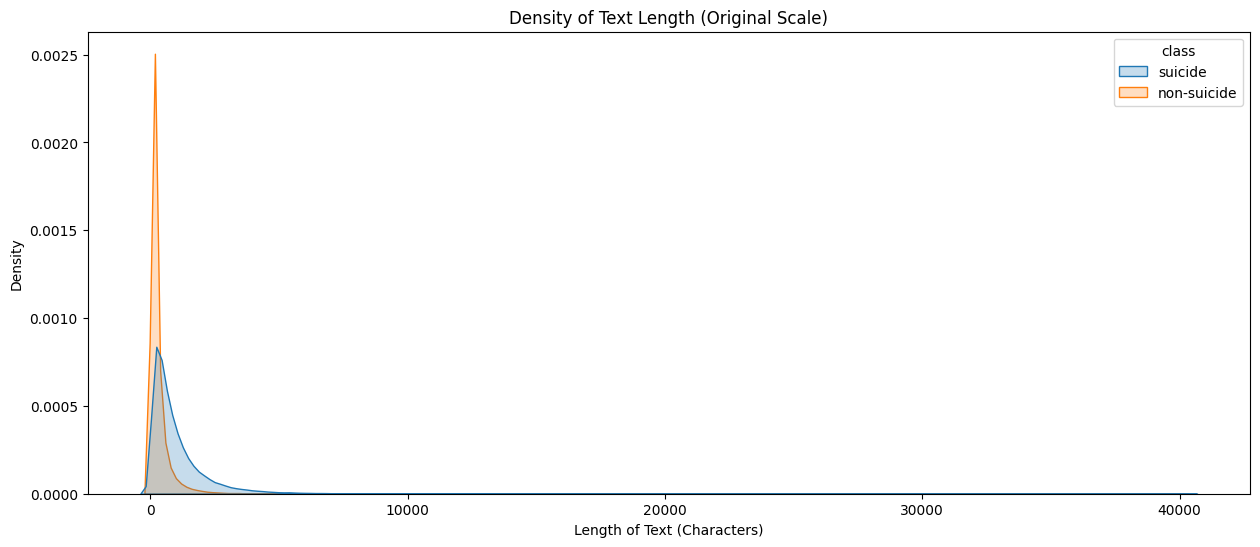

In [21]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data=df, x='text_len', hue='class', fill=True, common_norm=False)
plt.title('Density of Text Length (Original Scale)')
plt.xlabel('Length of Text (Characters)')
plt.ylabel('Density')
plt.show()

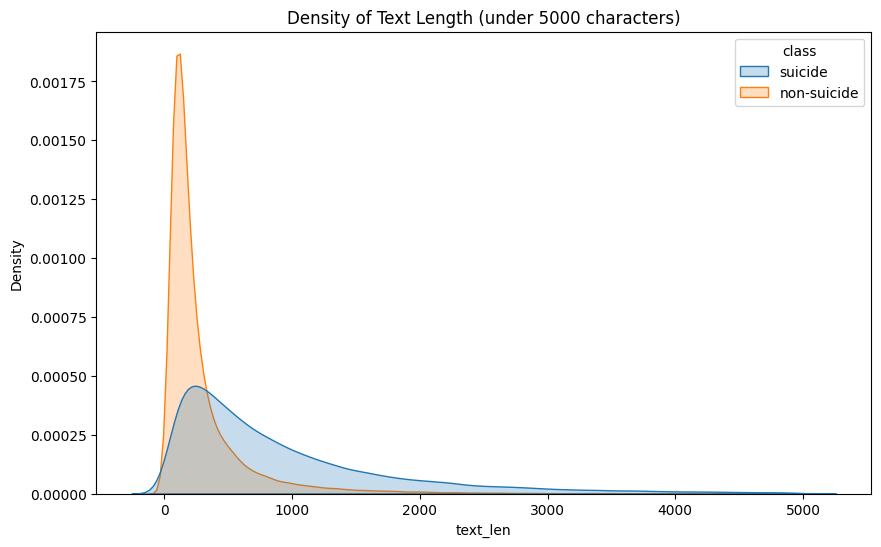

In [22]:
# observe: most text length fall within 5000, and suicide type tend to be longer content
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['text_len'] < 5000], x='text_len', hue='class', fill=True)
plt.title('Density of Text Length (under 5000 characters)')
plt.show()

In [23]:
# Look at the low end
df[df['text_len'] < 20]['text'].sample(20)

96056           I’m about to😞
75576      Clocks r cool af L
123211         Hi there! Hey!
135462        Wanna chat? 14f
102482      :(again and again
120265           I’m dyingRIP
193559     Have a hug ʕっ•ᴥ•ʔっ
208270     This is a test Yep
32940        I'm 16 today Pog
172726       See you laterbye
162492    9 more hours.Sorry.
228833            ByeΨσγχο...
119751         lunch time cya
223846                  :)bye
144680      without you now 🤧
209881    Hang myselfSaturday
69153     day 17 of hugs hugs
21188                    :/:/
41788      HelpSome inbox me.
160340       blood s kool Idk
Name: text, dtype: str

In [24]:
# Look at the very high end
high_end_df = df[df['text_len'] > 5000]['text']
if len(high_end_df) > 0:
    # If there are fewer than 50 high-end texts, show all of them.
    # Otherwise, sample 50.
    sample_count = min(50, len(high_end_df))
    print(high_end_df.sample(sample_count))
else:
    print("No texts found with length greater than 5000 characters.")

13839                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

Posts with fewer than 20 characters are not providing a useful signal. Posts with more than 5000 characters are also not useful because they look like blank spaces or spam.

In [25]:
# Drop rows where text_len > 5000 or < 20
df = df[(df['text_len'] >= 20) & (df['text_len'] <= 5000)]

In [26]:
print(f"Rows remaining: {len(df)}")
print(f"text_len range: {df['text_len'].min()} – {df['text_len'].max()}")
print(df['class'].value_counts())  # check class balance held up

Rows remaining: 229348
text_len range: 20 – 5000
class
non-suicide    115561
suicide        113787
Name: count, dtype: int64


In [27]:
# Look at the new low end
df[df['text_len'] < 50]['text'].sample(20)

220627      pleasethinking of ending it over and over again
170179            Being human is boring I wish I was a tree
43488               GgOnly around because of my huge fanily
14803                              Uuuuu w ? Uuuuuuuuu uuuu
182225             [16 F] will you be my valentine? ^_^ hmu
93608                           I broke up With my own hand
156961                          give coddit link me require
137334      yoyoyo its ya boi gimme ur fucking reddit coins
71180             Klondike bar for breakfest Poggie woggies
153541             Man I’m bored I don’t like today already
173657                  i'm gonna kill myselfprove me wrong
163541          The cake is a lie u/MisterCakelol exposed 😳
167772    I am sitting down Or am i?!?! You will never know
60623     Egg water Thank you all for coming to my TED talk
38513                    TonightTonight it's over. Good bye
158127                   I’m tiredAlso I care about you all
28235               Im going to b r e a 

In [28]:
# Look at the new high end
high_end_df = df[df['text_len'] > 4000]['text']
if len(high_end_df) > 0:
    # If there are fewer than 50 high-end texts, show all of them.
    # Otherwise, sample 50.
    sample_count = min(50, len(high_end_df))
    print(high_end_df.sample(sample_count))
else:
    print("No texts found with length greater than 5000 characters.")

229685                                                                                                                                                                                                                                                                                                                                                                                                When will life stop fucking me over?If you do not physically have the means to kill yourself right there &amp; then,but are still very depressed,the Suicide Hotline will tell you that “sorry but I have to move onto other people,now.”They will also do this if you do not immediately make the statement “Yes,I feel like ending my life right now”.Like if you just say that you feel like your life is worthless &amp; see no future or purpose of continuing your life......but don’t directly state you are about to take a life altering action,they will dump you off their line.They don’t want to talk to depressed pe

Posts with fewer than 50 characters still seem to not be providing much of a useful signal, but since the shorter posts skew to the non-suicide class, they can be left in. Posts with more than 4000 characters starting to look more useful. Many of them are padded with extra spaces that will be removed during cleaning.

In [29]:
# random sample to get a subset of 100,000 rows of data for our project, use randon_state to make sure it is the same subset
# df = df.sample(100000,random_state=42)
df = df.sample(10000,random_state=42)
df

,text,class,text_len
184182,"Fr advice time Dont be telling your girl (or boy) that you love them bruh. That shits a relationship killer if done prematurely. In my experience girls are the ones that be sayin it early, but yall seem like the type of guys to be sayin I love you after a month of dating in highschool.",non-suicide,288
9269,"Struggles of meeting someone you like for just one night. Few days ago I met a cute girl at a friend's party, but she lives like 30 km from me. We connected well and eventually made out but I think we both had the feeling it was just for one time, since we both wouldn't get the opportunity to see eachother more and... She apparantly cheated on her boyfriend by hooking up with me so I just feel shit ruining some guy's feelings... \nStill I feel somewhat emotionally attached to her and was wondering if others have went through the same thing sometime and what they did... because what better way to share your feelings than through strangers on the internet right??!!",non-suicide,670
215592,"Right, that's it.at 2:00AM (40 minutes from now), I'm ending it all. I have my gun of choice and the right ammunition ready, I'm only waiting now so I can eat my last meal and do a couple of other things. Other than that, goodbye.",suicide,230
225340,"Really suicidal...It just dawned to me how pathetic I am. More pathetic than 90% of this sub, r depression and r anxiety. \n\nI'm so subhuman that I cannot even relate to most of the problems people on this sub are having. ""Ever since my ex-girlfriend/wife left me..."", ""It's hard to kill yourself when you're a father/mother"", ""MY friends and my SO love me, but I'm only a bother to them..."".\n\nHow did I become this way? What did I do wrong? Am I really that subhuman?\n\nLife is horrifying. Why do I HAVE to fight depression, anxiety, bullying and loneliness while my peers are having a blast? My best years are flowing away. Why bother living? I've never been happy a day in my life. There was always something standing in the way.\n\nYeah, who gives a shot anyways? I'm not a hot girl, nor am I a hot guy, so, who would give a damn anyways. And don't dare you say that ""looks don't matter"".",suicide,888
130805,Please help and talkPlease please please someone talk to me or PM me I am having a really hard time,suicide,100
...,...,...,...
61798,just drove around the area now im herejust going to write my thoughts here cause i dont know where else to go. everyday i feel excluded i dont know why im feeling like this.. survived cancer in 2011 now i wish i hadnt and just shouldve died. just went for a drive past all my close friends house wishing they can just come outside and give me a hug.\ncontemplating on cutting.. but isnt that just for attention. why am i so needy,suicide,428
188405,"Thinking about killing myself but don't want to dieToo sum it up. I am 25 years old. I recently graduated from a reputable university with a degree in Film TV and new media. I can not seem to land a job for the life of me. I apply to atleast 2 jobs a day, based in CT here, mostly NY postings. LA has more postings/ offerings but i do not have the money to move out. I live with my parents and stupidly broke up with my girlfriend of 2 years who is dooing rather well in the same industry. We speak occasionally but she knows im a total loser. I've pretty much told myself if i cant do anything by 30 years of age im going to off myself. yet somehowe the feeling seems like it will come sooner. I cant find a job, my parents hate that i live at home, I cant find a ""significant other"" outisde of the girl ive foolishly dumped. I am an attractive dude and have no problems with women or tinder hook ups and can get laid constantly but none of this appeals to me. ideallly id love to get back together with my ex but she wants no part of it. I try looking for work in my field and have even started a youtube channel for gaming and memes in my spare time but not having a job no matter how hard i try, a

In [30]:
# check balance of classes after taking a smaller sample
df['class'].value_counts()

class
suicide        5027
non-suicide    4973
Name: count, dtype: int64

In [31]:
lemmatizer = WordNetLemmatizer()
stop_words = set(nltk.corpus.stopwords.words('english'))
punctuations = string.punctuation

In [32]:
def get_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [33]:
# Function to clean_text deep clean
def clean_text(text):
    text = re.sub(r'filler filler+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'fillerfiller+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text)
    text = text.translate(str.maketrans('', '', punctuations)).lower() #lowercase
    raw_tokens = nltk.word_tokenize(text)
    tagged_tokens = nltk.pos_tag(raw_tokens)
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
        if word not in stop_words and not word.isdigit()
    ]
    return ' '.join(tokens)

In [34]:
df['text_clean_deep'] = df['text'].apply(clean_text)

In [35]:
# Function to clean_text
def clean_for_deep_learning(text):
    text = re.sub(r'filler filler+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'fillerfiller+', '', text, flags=re.IGNORECASE)
    text = str(text)
    text = re.sub(r'\s+', ' ', text).lower() #lowercase
    return text.strip()

In [36]:
%%time

df['text_clean_mild'] = df['text'].apply(clean_for_deep_learning)

CPU times: total: 250 ms
Wall time: 236 ms


In [37]:
df[['text_clean_deep','text_clean_mild','text']].sample(5)

,text_clean_deep,text_clean_mild,text
231364,’ know whether want die notthe thought die give much pleasure make feel good pain end know ’ dead forever terrify fuck make sad life turn like wish thing would get good wish die ’ option hate people say “ suicide never option ” ’ one everything mess right know ’ terrible person thing probably get bad feel like issue deal different everybody else ’ know whether commit suicide ’ really young ’ tell thing get good,"i don’t know whether i want to die or notthe thought of dying gives me so much pleasure and makes me feel good because all the pain will end but knowing that i’ll be dead forever is just so terrifying. it fucking makes me so sad that my life has to turn out like this and i wish things would just get better. i wish dying didn’t have to be an option. i hate when people say “suicide is never an option” but it’s the only one for me, everything is a mess right now. i know i’m such a terrible person and things will probably just get worse. i feel like the issues i deal with are so different to everybody else. i don’t know whether to commit suicide or not, i’m really young but i can’t tell if things will get better.","I don’t know whether I want to die or notThe thought of dying gives me so much pleasure and makes me feel good because all the pain will end but knowing that I’ll be dead forever is just so terrifying. It fucking makes me so sad that my life has to turn out like this and I wish things would just get better. I wish dying didn’t have to be an option. I hate when people say “suicide is never an option” but it’s the only one for me, everything is a mess right now.\nI know I’m such a terrible person and things will probably just get worse. I feel like the issues I deal with are so different to everybody else. I don’t know whether to commit suicide or not, I’m really young but I can’t tell if things will get better."
152801,bully story early preschool ’ get make fun bc always quiet tho whole reason quiet anyway kind stuck thru elementary school middle school barely talk unbelievable social anxiety one know name honestly super surprise wan na hear different version story like ik mine ’ intense word make share never hurt anyone,"bullying stories early on in preschool i’d get made fun of bc i was always quiet, tho that was the whole reason for me being quiet anyway. kind of stuck with me thru elementary school and middle school, barely talked, had unbelievable social anxiety, no one knew my name and if they did i was honestly super surprised just wanna hear different versions of stories like this, ik mine isn’t as intense as the word makes it out to be, but sharing never hurt anyone","bullying stories Early on in preschool I’d get made fun of bc I was always quiet, tho that was the whole reason for me being quiet anyway. Kind of stuck with me thru elementary school and middle school, barely talked, had unbelievable social anxiety, no one knew my name and if they did I was honestly super surprised\n\njust wanna hear different versions of stories like this, ik mine isn’t as intense as the word makes it out to be, but sharing never hurt anyone"
95178,im full shiti say constantly im work thing think thing go get good woohoo end decade long 20teens youve problem curse decade least thats try say believe really know thats bullshit problem isnt year decade problem thats always go case matter hard try matter much lie get day week year real consistent thing fuck selfish manipulator cant hold job leech others emotion financeshell maybe happiness dont even gall subtle would good know true everyday voice head tell ive plan much ive waste much time might well go already gon na pretty idea hold back steadily fail dont care pretty death dont care clean care hurt anymore dont want hurt anymore,"i'm full of shit.i say constantly that i'm working on things. that i think things are going to get better. woohoo, 2020 is the end of the decade! so long 20teen's you've been the problem, you cursed dec

In [38]:
# Verify that no cells in cleaned combined text column are null
df['text_clean_deep'].isnull().sum()

np.int64(0)

In [39]:
# notice that there are one or more non-english records: remove all non-English records
def detect_english(text):
    try:
        return detect(str(text)[:200]) == 'en'
    except:
        return False
df['is_en'] = df['text'].apply(detect_english)
df_clean = df[df['is_en'] == True].copy()
df_clean = df_clean.drop(columns=['is_en'])

In [ ]:
df_clean[['text_clean_deep','text_clean_mild','text']].sample(5)
df_clean['label'] = df_clean['class'].map({'non-suicide': 0, 'suicide': 1})
df_clean.to_csv('df_clean.csv', index=False)

Sentiment Analysis **(VADER)**

In [41]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

In [42]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\wenli\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [43]:
# create analyzer
sia = SentimentIntensityAnalyzer()

In [44]:
# get sentiment score for each post
df_clean['sentiment_score'] = df_clean['text_clean_mild'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

print("Sample sentiment scores:")
df_clean[['text', 'class', 'sentiment_score']].sample(5)

Sample sentiment scores:


,text,class,sentiment_score
81876,"What are you scared of? I'm scared of really big and dark rooms. Where i don't know the shape of that room and where i am.\n\nTell me, idk I'm bored",non-suicide,-0.8074
116075,Guys Im Sorry I Lied I only ate 659 because my dog stole one.,non-suicide,-0.4404
159539,Hello lads Does anybody wanna play a game or some shit as it's fucking half 5 again and I make horrible decisions,non-suicide,-0.6908
23381,"What status does a girl have to get to to get invited to a boys sleepover? Does it even happen? Is it worth it? Bad idea? I've been seeing the guy getting into the girl's sleepover in hot, but does it work the other way?",non-suicide,-0.4137
129199,"Miserable no matter what I doWhen I'm unemployed I feel like a useless sack of shit, yet when I'm working I feel like my life has no meaning other than work. I don't even have time to do anything I like anymore. Lately, all my mornings consist of are me driving to work for an hour thinking about the least painful way to die. What is the point of living if you get 2 fucking days to enjoy in the week and the other 5 are you on auto pilot doing the same shit day in and day out, I seriously don't understand how anybody can live with this, and the weird part is I actually enjoy the work I do for the most part, which makes me feel even more stupid.\n\nI'm at a mental low I haven't been at for years. I don't really need advice or anything I just wanted to say this out loud, ranting sometimes helps.",suicide,-0.8796


In [45]:
# compare sentiment by class
sentiment_summary = df_clean.groupby('class')['sentiment_score'].mean()

print("Average sentiment by class:")
print(sentiment_summary)

Average sentiment by class:
class
non-suicide    0.100960
suicide       -0.388174
Name: sentiment_score, dtype: float64


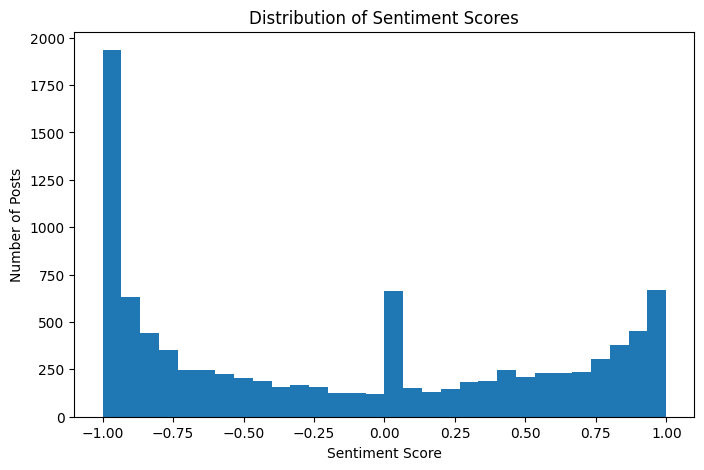

In [46]:
# distribution of sentiment scores
plt.figure(figsize=(8, 5))
plt.hist(df_clean['sentiment_score'], bins=30)

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Posts")

plt.show()

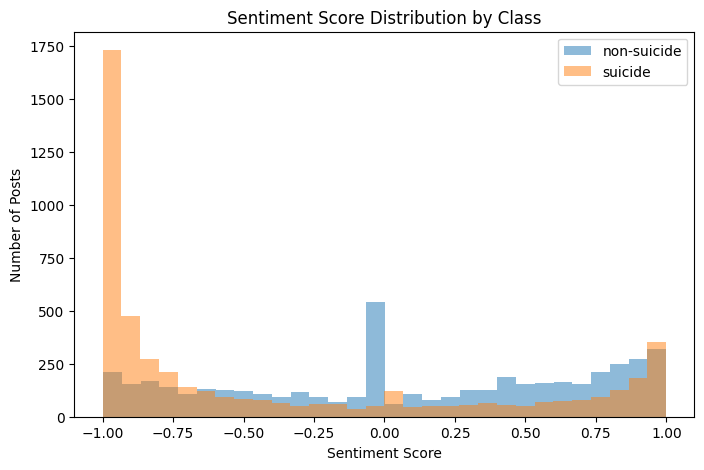

In [47]:
# sentiment distribution by class
plt.figure(figsize=(8, 5))

for label in df_clean['class'].unique():
    plt.hist(
        df_clean[df_clean['class'] == label]['sentiment_score'],
        bins=30,
        alpha=0.5,
        label=label
    )

plt.title("Sentiment Score Distribution by Class")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Posts")
plt.legend()

plt.show()

#suicidal posts tend to have lower sentiment scores on average
It’s interesting to see the distribution of the sentiment score by class… Yes, there’s a big spike in very low scores for the Suicide class, and a good spike in neutral scores for the non-suicide class, but otherwise both classes are distributed similarly.

**EDA**: word cloud for suicide_data & non_suicide_data



In [48]:
suicide_data = df[df['class'] == 'suicide']['text_clean_deep']
non_suicide_data = df[df['class'] == 'non-suicide']['text_clean_deep']

In [49]:
text_suicide = " ".join(str(i) for i in suicide_data)
text_non_suicide = " ".join(str(i) for i in non_suicide_data)

In [50]:
def generate_wc(text, title, color):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=color,
        max_words=150
    ).generate(text)

    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=14)
    plt.axis('off')

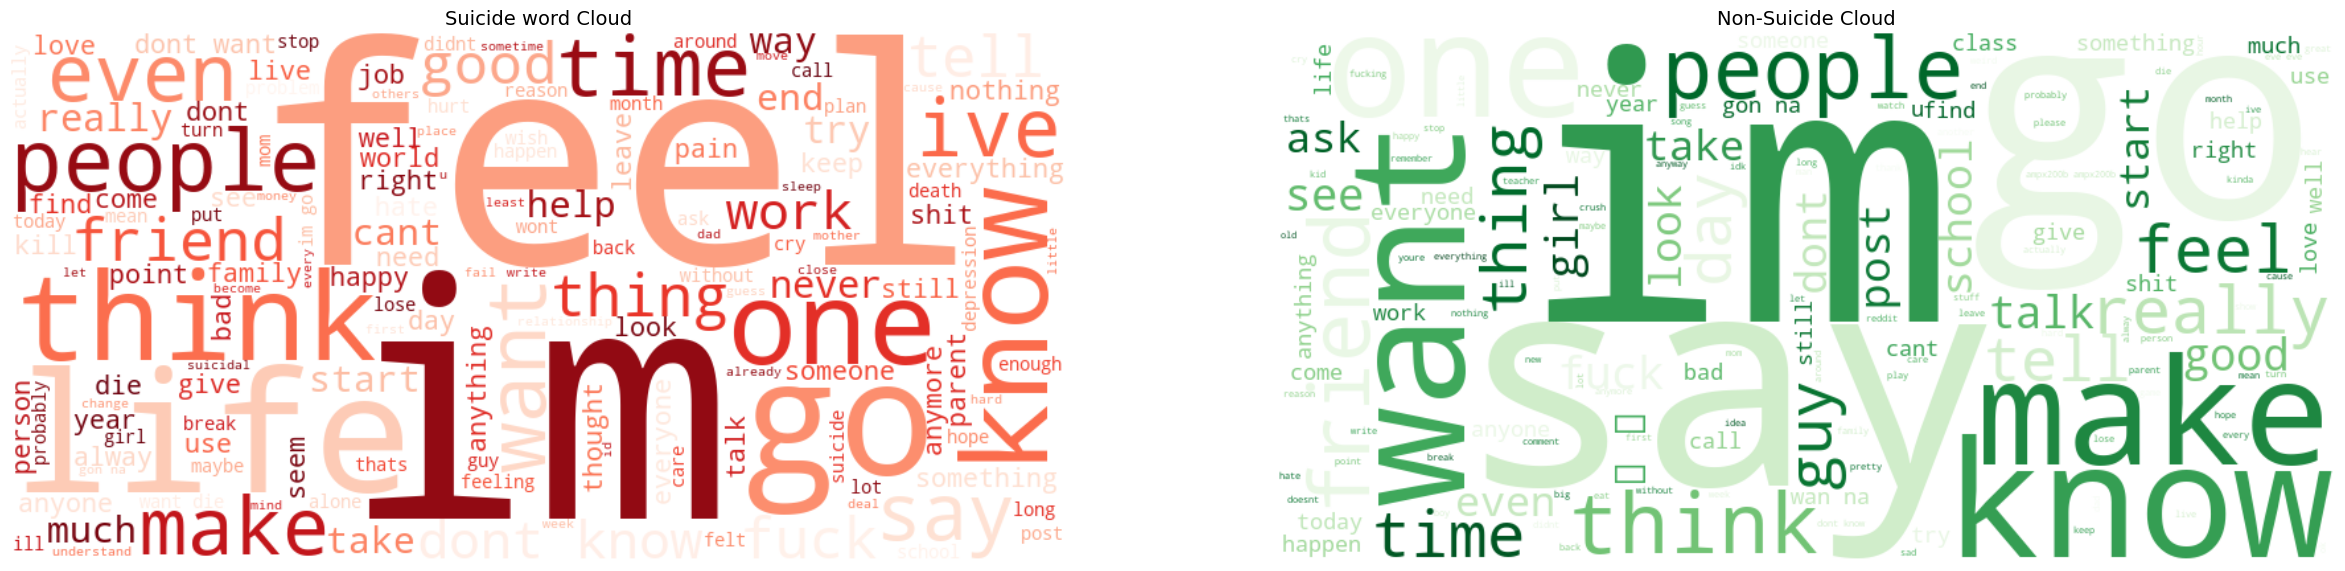

In [51]:
# Generate word cloud
plt.figure(figsize=(30, 20))
plt.subplot(1, 2, 1)
generate_wc(text_suicide, 'Suicide word Cloud', 'Reds')
# Generate word cloud
plt.subplot(1, 2, 2)
generate_wc(text_non_suicide, 'Non-Suicide Cloud', 'Greens')

plt.show()

---
## Topic Modeling with BERTopic

Before moving into classification, we apply BERTopic to explore the latent thematic structure of the corpus. Unlike the classification models below, BERTopic is **unsupervised** — it discovers topics without using the `class` label. This lets us examine whether the textual content naturally clusters in ways that align with the suicide vs. non-suicide distinction.

BERTopic chains three steps: (1) sentence embeddings via a pretrained transformer, (2) dimensionality reduction with UMAP, and (3) density-based clustering with HDBSCAN. c-TF-IDF is then used to extract the most representative words per cluster.

**Dataset scope:** BERTopic is run on the **full filtered dataset** (`df` before the 10,000-row sample) so the topic structure reflects the complete corpus. The 10,000-row sample used for classification is drawn afterwards.

In [52]:
import warnings
warnings.filterwarnings('ignore', category=SyntaxWarning)
from bertopic import BERTopic
import re

print(f'Full filtered dataset size: {len(df):,} rows')
print(df['class'].value_counts())

Full filtered dataset size: 10,000 rows
class
suicide        5027
non-suicide    4973
Name: count, dtype: int64


In [53]:
# BERTopic works best with light cleaning — preserves semantic context
# We reuse clean_for_deep_learning (mild clean) applied to the full df
def clean_for_bertopic(text):
    text = re.sub(r'filler filler+', '', str(text), flags=re.IGNORECASE)
    text = re.sub(r'fillerfiller+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).lower()
    return text.strip()

In [54]:
%%time
df['text_bertopic'] = df['text'].apply(clean_for_bertopic)
print(f'Cleaned {len(df):,} documents for BERTopic')

Cleaned 10,000 documents for BERTopic
CPU times: total: 250 ms
Wall time: 239 ms


### Fit BERTopic on the full corpus

We fit a single model on all documents (both classes combined) to discover topics organically, then inspect whether topics skew toward one class.

In [55]:
%%time

# Instantiate BERTopic with default settings (all-MiniLM-L6-v2 embeddings)
# min_topic_size controls the minimum cluster size — lower = more granular topics
topic_model = BERTopic(min_topic_size=50, verbose=True)
topics, probs = topic_model.fit_transform(df['text_bertopic'].tolist())

2026-05-12 15:25:51,596 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 313/313 [02:36<00:00,  2.00it/s]
2026-05-12 15:28:29,483 - BERTopic - Embedding - Completed ✓
2026-05-12 15:28:29,485 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-12 15:28:56,302 - BERTopic - Dimensionality - Completed ✓
2026-05-12 15:28:56,304 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-12 15:28:56,837 - BERTopic - Cluster - Completed ✓
2026-05-12 15:28:56,841 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-12 15:28:57,437 - BERTopic - Representation - Completed ✓


CPU times: total: 21min 11s
Wall time: 3min 5s


In [56]:
from sklearn.feature_extraction.text import CountVectorizer

# Update topic representations to exclude stopwords (no retraining needed)
vectorizer = CountVectorizer(stop_words='english')
topic_model.update_topics(df['text_bertopic'].tolist(), vectorizer_model=vectorizer)

In [57]:
# Overview of discovered topics
# Topic -1 = outlier documents that don't fit any cluster
topic_info = topic_model.get_topic_info()
print(f'Total topics discovered (excl. outliers): {len(topic_info) - 1}')
print(f'Outlier documents (Topic -1): {topic_info[topic_info.Topic == -1]["Count"].values[0]:,}')
topic_info.head(15)

Total topics discovered (excl. outliers): 15
Outlier documents (Topic -1): 3,102


Topic  Count                                Name  \
0      -1   3102                -1_im_just_like_dont   
1       0   4854                 0_im_just_dont_want   
2       1    307             1_pizza_eat_water_crust   
3       2    304              2_girl_crush_like_said   
4       3    224         3_teacher_class_school_test   
5       4    205          4_song_music_songs_spotify   
6       5    180            5_apple_post_reddit_rant   
7       6    127               6_bored_dm_chat_wanna   
8       7    124              7_sleep_wake_night_bed   
9       8    113         8_trans_gender_straight_gay   
10      9    103  9_fonrite_fonrtefornite_games_play   
11     10     88          10_eve_birthday_content_30   
12     11     74            11_talk_need_just_lonely   
13     12     72        12_covid_trigger_mask_school   
14     13     62           13_award_awards_coins_cad   

                                                                          Representation  \
0                      [im, just, like, dont, people, ampx200b, know, want, day, really]   
1                              [im, just, dont, want, like, life, feel, know, ive, time]   
2                     [pizza, eat, water, crust, cheese, bird, dentist, just, like, cat]   
3                       [girl, crush, like, said, just, really, im, asked, friend, shes]   
4   [teacher, class, school, test, homework, online, teachers, assignments, math, grade]   
5          [song, music, songs, spotify, lie, lyrics, listening, like, listen, playlist]   
6             [apple, post, reddit, rant, banned, wanna, people, subreddit, posts, just]   
7                          [bored, dm, chat, wanna, talk, im, saw, came, ampx200b, want]   
8                   [sleep, wake, night, bed, im, awake, time, goodnight, blanket, late]   
9     [trans, gender, straight, gay, people, super, transphobic, lgbtq, attracted, lgbt]   
10  [fonrite, fonrtefornite, games, play, game, fortnite, mobile, xbox, playing, switch]   
11                      [eve, birthday, content, 30, years, happy, day, today, im, year]   
12                      [talk, need, just, lonely, want, dont, pm, really, help, filter]   
13       [covid, trigger, mask, school, wear, masks, boxers, virus, quarantine, covid19]   
14          [award, awards, coins, cad, free, wholesome, fuck, reddit, filler, platinum]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [58]:
# Top words for each of the first 10 topics
topic_model.get_topic_info()[['Topic', 'Count', 'Name']].head(11)

,Topic,Count,Name
0,-1,3102,-1_im_just_like_dont
1,0,4854,0_im_just_dont_want
2,1,307,1_pizza_eat_water_crust
3,2,304,2_girl_crush_like_said
4,3,224,3_teacher_class_school_test
5,4,205,4_song_music_songs_spotify
6,5,180,5_apple_post_reddit_rant
7,6,127,6_bored_dm_chat_wanna
8,7,124,7_sleep_wake_night_bed
9,8,113,8_trans_gender_straight_gay


In [59]:
# Visualize word bar chart for top 10 topics
topic_model.visualize_barchart(top_n_topics=10, n_words=6)

### Topic distribution by class

We now attach the predicted topic to each document and compare topic distributions across the `suicide` and `non-suicide` classes.

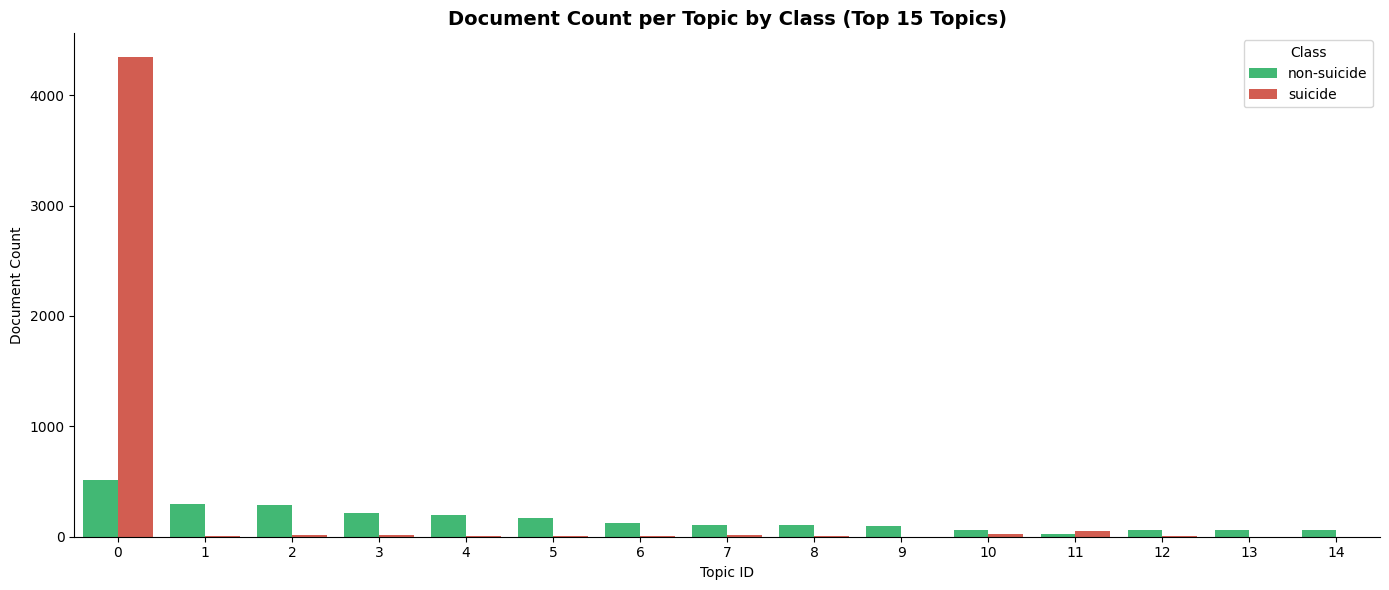

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Attach topics back to the full df
df_bt = df.copy()
df_bt['topic'] = topics

# Exclude outliers (topic -1) for distribution analysis
df_bt_filtered = df_bt[df_bt['topic'] != -1]

# Count topic assignments per class
topic_class_counts = (
    df_bt_filtered
    .groupby(['topic', 'class'])
    .size()
    .reset_index(name='count')
)

# Top 15 topics by total document count
top_topics = (
    topic_class_counts.groupby('topic')['count'].sum()
    .nlargest(15).index.tolist()
)
plot_df = topic_class_counts[topic_class_counts['topic'].isin(top_topics)]

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_df, x='topic', y='count', hue='class',
            palette={'suicide': '#e74c3c', 'non-suicide': '#2ecc71'})
plt.title('Document Count per Topic by Class (Top 15 Topics)', fontsize=14, fontweight='bold')
plt.xlabel('Topic ID')
plt.ylabel('Document Count')
plt.legend(title='Class')
sns.despine()
plt.tight_layout()
plt.show()

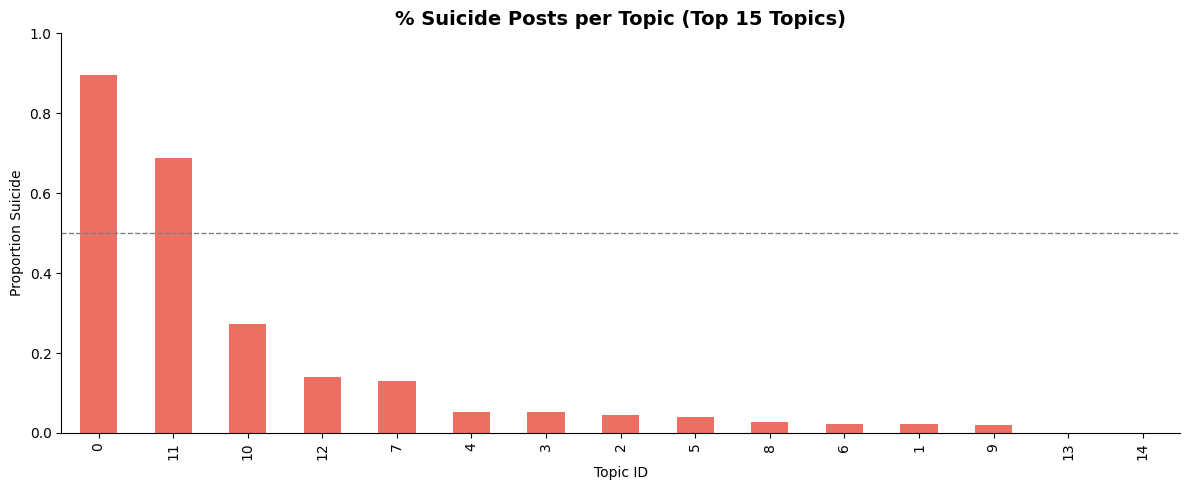

class  suicide  non-suicide   total  pct_suicide
topic                                           
0       4344.0        510.0  4854.0     0.894932
11        51.0         23.0    74.0     0.689189
10        24.0         64.0    88.0     0.272727
12        10.0         62.0    72.0     0.138889
7         16.0        108.0   124.0     0.129032
4         11.0        194.0   205.0     0.053659
3         12.0        212.0   224.0     0.053571
2         14.0        290.0   304.0     0.046053
5          7.0        173.0   180.0     0.038889
8          3.0        110.0   113.0     0.026549
6          3.0        124.0   127.0     0.023622
1          7.0        300.0   307.0     0.022801
9          2.0        101.0   103.0     0.019417
13         0.0         62.0    62.0     0.000000
14         0.0         61.0    61.0     0.000000


In [61]:
# Proportion of each class within each topic
topic_pivot = (
    topic_class_counts[topic_class_counts['topic'].isin(top_topics)]
    .pivot(index='topic', columns='class', values='count')
    .fillna(0)
)
topic_pivot['total'] = topic_pivot.sum(axis=1)
topic_pivot['pct_suicide'] = topic_pivot['suicide'] / topic_pivot['total']
topic_pivot = topic_pivot.sort_values('pct_suicide', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
topic_pivot['pct_suicide'].plot(kind='bar', color='#e74c3c', alpha=0.8, ax=ax)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_title('% Suicide Posts per Topic (Top 15 Topics)', fontsize=14, fontweight='bold')
ax.set_xlabel('Topic ID')
ax.set_ylabel('Proportion Suicide')
ax.set_ylim(0, 1)
sns.despine()
plt.tight_layout()
plt.show()

print(topic_pivot[['suicide', 'non-suicide', 'total', 'pct_suicide']].to_string())

### Class-specific topic models

We also fit BERTopic **separately** on each class to surface the distinct themes within suicide and non-suicide posts. This provides a richer picture than the combined model alone.

In [62]:
%%time

suicide_docs     = df[df['class'] == 'suicide']['text_bertopic'].tolist()
non_suicide_docs = df[df['class'] == 'non-suicide']['text_bertopic'].tolist()

topic_model_suicide     = BERTopic(min_topic_size=40, verbose=False)
topic_model_non_suicide = BERTopic(min_topic_size=40, verbose=False)

topics_s,  _ = topic_model_suicide.fit_transform(suicide_docs)
topics_ns, _ = topic_model_non_suicide.fit_transform(non_suicide_docs)

print(f'Suicide topics:     {len(topic_model_suicide.get_topic_info()) - 1}')
print(f'Non-suicide topics: {len(topic_model_non_suicide.get_topic_info()) - 1}')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8648.05it/s]


Suicide topics:     2
Non-suicide topics: 20
CPU times: total: 21min 32s
Wall time: 2min 52s


In [63]:
# Update class-specific models to exclude stopwords
topic_model_suicide.update_topics(suicide_docs, vectorizer_model=CountVectorizer(stop_words='english'))
topic_model_non_suicide.update_topics(non_suicide_docs, vectorizer_model=CountVectorizer(stop_words='english'))

In [64]:
print('=== Top Suicide Topics ===')
display(topic_model_suicide.get_topic_info().head(11))

print('\n=== Top Non-Suicide Topics ===')
display(topic_model_non_suicide.get_topic_info().head(11))

=== Top Suicide Topics ===


Topic  Count                  Name  \
0     -1   1193  -1_im_just_dont_want   
1      0   3704   0_im_just_dont_like   
2      1    130  1_pills_im_just_want   

                                                  Representation  \
0    [im, just, dont, want, like, feel, know, life, ive, people]   
1    [im, just, dont, like, want, feel, life, know, ive, people]   
2  [pills, im, just, want, dont, die, took, know, overdose, ive]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             


=== Top Non-Suicide Topics ===


Topic  Count                             Name  \
0      -1   2479             -1_im_like_just_dont   
1       0    373             0_bored_dm_play_talk   
2       1    263           1_crush_girl_like_said   
3       2    236              2_im_just_feel_life   
4       3    211      3_song_music_songs_solonnla   
5       4    205  4_school_class_teacher_homework   
6       5    196       5_apple_post_reddit_people   
7       6    133         6_pizza_eat_crust_cheese   
8       7    122            7_sleep_night_wake_im   
9       8    113      8_gay_trans_straight_gender   
10      9     93     9_birthday_content_happy_day   

                                                                       Representation  \
0                   [im, like, just, dont, people, know, ampx200b, want, really, day]   
1                 [bored, dm, play, talk, chat, wanna, discord, game, fonrite, games]   
2                  [crush, girl, like, said, just, friend, really, know, im, friends]   
3                       [im, just, feel, life, dont, like, people, want, really, ive]   
4   [song, music, songs, solonnla, nmivmir, spotify, listen, like, lyrics, listening]   
5            [school, class, teacher, homework, grades, test, online, dont, work, im]   
6                 [apple, post, reddit, people, rant, banned, wanna, 11, like, memes]   
7                  [pizza, eat, crust, cheese, hut, ate, milk, manager, just, eating]   
8           [sleep, night, wake, im, sleeping, tired, bed, goodnight, awake, morning]   
9                  [gay, trans, straight, gender, people, super, men, male, im, just]   
10               [birthday, content, happy, day, today, 18, year, im, world, release]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [65]:
# Suicide posts — top topics
fig_suicide = topic_model_suicide.visualize_barchart(top_n_topics=5, n_words=6)
fig_suicide.update_layout(title_text='Suicide Posts — Top Topics')
fig_suicide.show()

In [66]:
# Non-suicide posts — top topics
fig_non_suicide = topic_model_non_suicide.visualize_barchart(top_n_topics=5, n_words=6)
fig_non_suicide.update_layout(title_text='Non-Suicide Posts — Top Topics')
fig_non_suicide.show()

### Reduce to top N topics

To simplify interpretation, we reduce the combined model to the top 10 topics.

In [67]:
# Reduce combined model to top 10 topics
topic_model_reduced = topic_model.reduce_topics(df['text_bertopic'].tolist(), nr_topics=10)

print('Reduced topic info:')
topic_model_reduced.get_topic_info()

Reduced topic info:


Topic  Count                                Name  \
0     -1   3102                -1_im_just_like_dont   
1      0   4854                 0_im_just_dont_want   
2      1    494             1_apple_post_talk_wanna   
3      2    379               2_pizza_eat_just_like   
4      3    348        3_school_teacher_sleep_class   
5      4    304              4_girl_crush_like_said   
6      5    205          5_song_music_songs_spotify   
7      6    164  6_fonrite_fonrtefornite_games_play   
8      7     88           7_eve_birthday_content_30   
9      8     62            8_award_awards_coins_cad   

                                                                     Representation  \
0                 [im, just, like, dont, people, know, want, ampx200b, really, day]   
1                         [im, just, dont, want, like, feel, life, know, ive, time]   
2                     [apple, post, talk, wanna, bored, dm, just, people, im, chat]   
3                   [pizza, eat, just, like, water, im, crust, covid, cheese, bird]   
4             [school, teacher, sleep, class, im, test, just, homework, dont, like]   
5                  [girl, crush, like, said, just, im, really, friend, asked, shes]   
6     [song, music, songs, spotify, lie, like, listening, lyrics, listen, playlist]   
7  [fonrite, fonrtefornite, games, play, game, movie, watch, anime, fortnite, good]   
8                [eve, birthday, content, 30, years, day, happy, today, im, people]   
9          [award, awards, coins, cad, free, fuck, wholesome, reddit, filler, shit]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [68]:
topic_model_reduced.visualize_barchart(n_words=6)

### BERTopic Summary

BERTopic reveals the latent thematic structure of the corpus without using any labels. Topics dominated by suicidal ideation language (e.g., clusters around self-harm, hopelessness, or crisis) that naturally separate from non-suicide topics suggest the content itself is semantically distinct — supporting the feasibility of the classification task that follows.

The class-specific models offer an additional lens: what themes are most central *within* each class, independent of the other.

---